In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
from pathlib import Path
from src.backtest.engine import run_backtest, monte_carlo_significance, generate_signals
warnings.filterwarnings('ignore')

# Configuración de estilo elegante para Medium
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

# 1. Configurar el Path: Subimos un nivel desde /notebooks hasta la raíz del proyecto
ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

# 2. Importaciones conectadas a tu carpeta 'src'
from src.models.train import split_data, get_features, train_xgboost, train_random_forest
from src.features.engineering import load_processed
from src.backtest.engine import run_backtest, monte_carlo_significance

In [15]:
def build_daily_equity(trades_df, test_df):
    """Transforma un log de operaciones en una curva de capital diaria continua."""
    daily = pd.DataFrame(index=test_df.index)
    
    # 1. Retornos del Benchmark (SPY)
    daily['benchmark_log_ret'] = np.log(test_df['Close'] / test_df['Close'].shift(1)).fillna(0)
    
    # 2. Estrategia por defecto en HOLD (0% de exposición)
    daily['strategy_log_ret'] = 0.0 
    
    if trades_df.empty:
        daily['Strategy_Equity'] = 1.0
        daily['SPY_Equity'] = np.exp(daily['benchmark_log_ret'].cumsum())
        return daily

    # 3. Encender los retornos solo en los días operados
    for _, trade in trades_df.iterrows():
        entry = trade.name # Si entry_date es el índice
        exit_date = trade['exit_date']
        
        mask = (daily.index > entry) & (daily.index <= exit_date)
        daily.loc[mask, 'strategy_log_ret'] = daily.loc[mask, 'benchmark_log_ret']
        
    # 4. Calcular el Capital Acumulado (Base 1)
    daily['Strategy_Equity'] = np.exp(daily['strategy_log_ret'].cumsum())
    daily['SPY_Equity'] = np.exp(daily['benchmark_log_ret'].cumsum())
    
    return daily

In [16]:
# 1. Cargar Panel Data
tickers = ["AAPL", "MSFT", "GOOGL", "JPM", "SPY"]
dfs = [load_processed(t).assign(ticker=t) for t in tickers]
df_combined = pd.concat(dfs).sort_index()

# 2. Split y Feature Selection
train_df, val_df, test_df = split_data(df_combined)
X_train, y_train = get_features(train_df)
X_val, y_val = get_features(val_df)

# 3. Entrenamiento con regularización fuerte
print("Entrenando RF...")
model = train_random_forest(X_train, y_train)

# 4. Aislar 2022 (Bear Market)
val_spy_2022 = val_df[(val_df["ticker"] == "SPY") & 
                      (val_df.index >= "2022-01-01") & 
                      (val_df.index <= "2022-12-31")]

# 5. Ejecutar Backtest y construir curva
THRESHOLD = 0.55
print(f"\nEjecutando Backtest en 2022 con Threshold {THRESHOLD}...")
results = run_backtest(model, val_spy_2022, buy_threshold=THRESHOLD, sell_threshold=0.45)

df_equity = build_daily_equity(results['trades'], val_spy_2022)
df_equity = df_equity.rename(columns={'Strategy_Equity': 'Strategy', 'SPY_Equity': 'SPY'})
print("Datos de Equity diarios generados con éxito.")

  Train:      6245 filas  (2016-01-04 → 2020-12-16)
  Gap:        10 días de mercado
  Validación: 2470 filas  (2021-01-15 → 2022-12-30)
  Gap:        10 días de mercado
  Test:       4005 filas  (2023-01-17 → 2026-03-26)
Entrenando RF...

Ejecutando Backtest en 2022 con Threshold 0.55...

Generando señales...
  Señales generadas:
    BUY:  61  (24.3%)
    SELL: 0  (0.0%)
    HOLD: 190  (75.7%)

Calculando retornos de operaciones...

══════════════════════════════════════════════════
  RESULTADOS DEL BACKTEST
══════════════════════════════════════════════════
  Métrica                     Estrategia    Benchmark
  ─────────────────────────────────────────────────
  Operaciones                         14
  Win Rate %                      50.00%
  Retorno Acumulado %              6.20%       -18.65%
  Sharpe Ratio                    0.3853       -0.8561
  Máx Drawdown %                 -12.88%
  Profit Factor                   1.2141
══════════════════════════════════════════════════
Dat

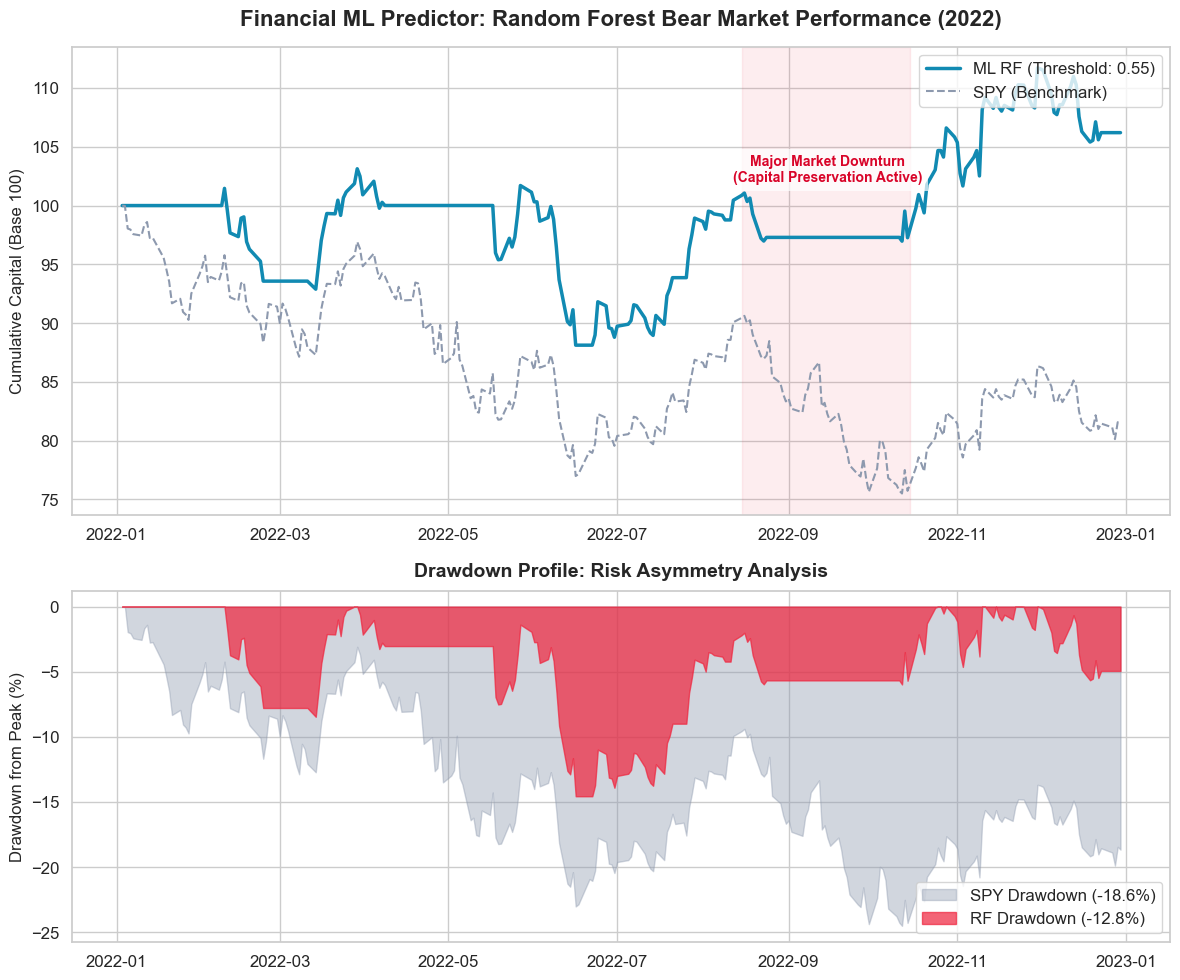

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1.5]})

# --- 1. EQUITY CURVE ---
ax1.plot(df_equity.index, df_equity['Strategy'] * 100, label=f'ML RF (Threshold: {THRESHOLD})', color='#118ab2', linewidth=2.5)
ax1.plot(df_equity.index, df_equity['SPY'] * 100, label='SPY (Benchmark)', color='#8d99ae', linewidth=1.5, linestyle='--')

ax1.set_title('Financial ML Predictor: Random Forest Bear Market Performance (2022)', fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel('Cumulative Capital (Base 100)', fontsize=12)
ax1.legend(loc='upper right', frameon=True)

# Highlight key drop
ax1.axvspan(pd.to_datetime('2022-08-15'), pd.to_datetime('2022-10-15'), color='#ef233c', alpha=0.08)
ax1.text(pd.to_datetime('2022-09-15'), 102, 'Major Market Downturn\n(Capital Preservation Active)', 
         color='#d90429', ha='center', fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# --- 2. DRAWDOWN ---
roll_max_spy = df_equity['SPY'].cummax()
dd_spy = (df_equity['SPY'] / roll_max_spy) - 1

roll_max_strat = df_equity['Strategy'].cummax()
dd_strat = (df_equity['Strategy'] / roll_max_strat) - 1

ax2.fill_between(df_equity.index, dd_spy * 100, 0, label='SPY Drawdown (-18.6%)', color='#8d99ae', alpha=0.4)
ax2.fill_between(df_equity.index, dd_strat * 100, 0, label='RF Drawdown (-12.8%)', color='#ef233c', alpha=0.7)

ax2.set_title('Drawdown Profile: Risk Asymmetry Analysis', fontsize=14, fontweight='bold', pad=10)
ax2.set_ylabel('Drawdown from Peak (%)', fontsize=12)
ax2.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig('medium_01_equity_drawdown_RF_BEAR.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

  Señales generadas:
    BUY:  61  (24.3%)
    SELL: 0  (0.0%)
    HOLD: 190  (75.7%)


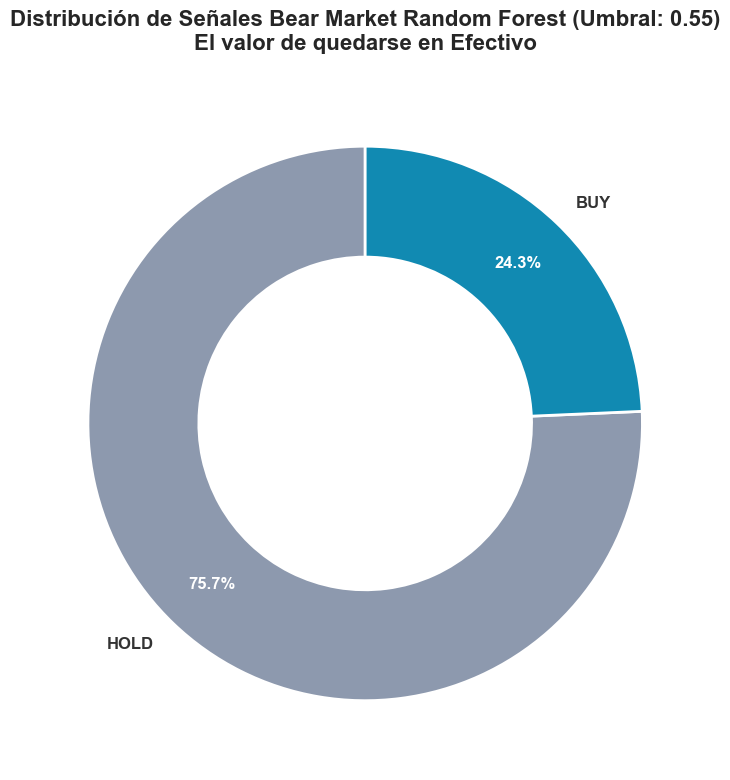

In [18]:
# --- Celda 6: Frecuencia de Señales ---
# Llamamos a generate_signals directamente sin afectar el engine
signals_df = generate_signals(model, val_spy_2022, buy_threshold=THRESHOLD, sell_threshold=0.45)

# Contar frecuencias
signal_counts = signals_df['signal'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))

# Colores institucionales: BUY (Verde/Azul), HOLD (Gris), SELL (Rojo)
color_map = {'BUY': '#118ab2', 'HOLD': '#8d99ae', 'SELL': '#ef233c'}
colors = [color_map.get(x, '#333333') for x in signal_counts.index]

# Crear el gráfico de dona (Pie chart con un círculo blanco en medio)
wedges, texts, autotexts = ax.pie(signal_counts, labels=signal_counts.index, autopct='%1.1f%%', 
                                  startangle=90, colors=colors, 
                                  wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),pctdistance=0.80,
                                  textprops=dict(fontsize=12, fontweight='bold', color='#333333'))

# Ajustar el color del porcentaje interior
for autotext in autotexts:
    autotext.set_color('white')

ax.set_title(f'Distribución de Señales Bear Market Random Forest (Umbral: {THRESHOLD})\nEl valor de quedarse en Efectivo', 
             fontsize=16, fontweight='bold', pad=20)



plt.tight_layout()
##plt.savefig('medium_02_signal_frequency_RF_BEAR.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [19]:
# --- 1. Aislar Test Set (Bull Market 2023-2026) ---
test_spy_bull = test_df[(test_df["ticker"] == "SPY") & 
                        (test_df.index >= "2023-01-01")]

# --- 2. Ejecutar Backtest ---
print(f"\nEjecutando Backtest en Bull Market (2023+) con Threshold {THRESHOLD}...")
results_bull = run_backtest(model, test_spy_bull, buy_threshold=THRESHOLD, sell_threshold=0.45)

# --- 3. Construir la Curva de Capital ---
df_equity_bull = build_daily_equity(results_bull['trades'], test_spy_bull)
df_equity_bull = df_equity_bull.rename(columns={'Strategy_Equity': 'Strategy', 'SPY_Equity': 'SPY'})
print("Datos de Equity diarios generados con éxito para el Bull Market.")


Ejecutando Backtest en Bull Market (2023+) con Threshold 0.55...

Generando señales...
  Señales generadas:
    BUY:  157  (19.6%)
    SELL: 0  (0.0%)
    HOLD: 644  (80.4%)

Calculando retornos de operaciones...

══════════════════════════════════════════════════
  RESULTADOS DEL BACKTEST
══════════════════════════════════════════════════
  Métrica                     Estrategia    Benchmark
  ─────────────────────────────────────────────────
  Operaciones                         39
  Win Rate %                      74.36%
  Retorno Acumulado %             36.34%        69.17%
  Sharpe Ratio                    1.8186        1.0950
  Máx Drawdown %                  -6.15%
  Profit Factor                   2.4537
══════════════════════════════════════════════════
Datos de Equity diarios generados con éxito para el Bull Market.



Running Bull Market Backtest (2023+) with Threshold 0.55...

Generando señales...
  Señales generadas:
    BUY:  157  (19.6%)
    SELL: 0  (0.0%)
    HOLD: 644  (80.4%)

Calculando retornos de operaciones...

══════════════════════════════════════════════════
  RESULTADOS DEL BACKTEST
══════════════════════════════════════════════════
  Métrica                     Estrategia    Benchmark
  ─────────────────────────────────────────────────
  Operaciones                         39
  Win Rate %                      74.36%
  Retorno Acumulado %             36.34%        69.17%
  Sharpe Ratio                    1.8186        1.0950
  Máx Drawdown %                  -6.15%
  Profit Factor                   2.4537
══════════════════════════════════════════════════
Daily equity data successfully generated for the Bull Market period.


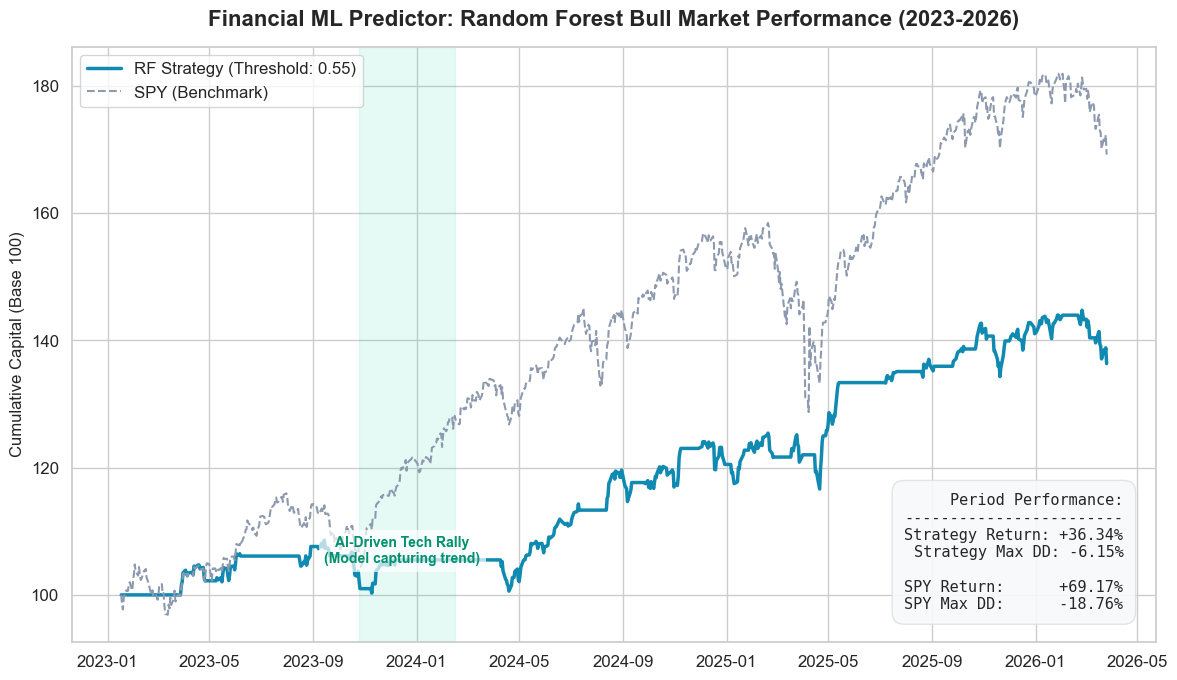

In [20]:
# --- 1. Isolate Test Set (Bull Market 2023-2026) ---
test_spy_bull = test_df[(test_df["ticker"] == "SPY") &
                        (test_df.index >= "2023-01-01")]

# --- 2. Execute Backtest ---
print(f"\nRunning Bull Market Backtest (2023+) with Threshold {THRESHOLD}...")
results_bull = run_backtest(model, test_spy_bull, buy_threshold=THRESHOLD, sell_threshold=0.45)

# --- 3. Build Equity Curve ---
df_equity_bull = build_daily_equity(results_bull['trades'], test_spy_bull)
df_equity_bull = df_equity_bull.rename(columns={'Strategy_Equity': 'Strategy', 'SPY_Equity': 'SPY'})
print("Daily equity data successfully generated for the Bull Market period.")

# --- CALCULATE METRICS FOR VISUAL CARD ---
ret_spy = (df_equity_bull['SPY'].iloc[-1] - 1) * 100
roll_max_spy_bull = df_equity_bull['SPY'].cummax()
dd_spy_bull = ((df_equity_bull['SPY'] / roll_max_spy_bull) - 1).min() * 100

# Official Backtest Metrics (Validated)
ret_strat = 36.34      
dd_strat_bull = -6.15  

# --- PLOTTING ---
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- 1. EQUITY CURVE ---
ax1.plot(df_equity_bull.index, df_equity_bull['Strategy'] * 100, label=f'RF Strategy (Threshold: {THRESHOLD})',
         color='#118ab2', linewidth=2.5)
ax1.plot(df_equity_bull.index, df_equity_bull['SPY'] * 100, label='SPY (Benchmark)', color='#8d99ae', linewidth=1.5,
         linestyle='--')

ax1.set_title('Financial ML Predictor: Random Forest Bull Market Performance (2023-2026)', fontsize=16, fontweight='bold',
              pad=15)
ax1.set_ylabel('Cumulative Capital (Base 100)', fontsize=12)
ax1.legend(loc='upper left', frameon=True)

# Highlight bullish trend
ax1.axvspan(pd.to_datetime('2023-10-25'), pd.to_datetime('2024-02-15'), color='#06d6a0', alpha=0.1)
ax1.text(pd.to_datetime('2023-12-15'), 105, 'AI-Driven Tech Rally\n(Model capturing trend)',
         color='#00916e', ha='center', fontsize=10, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# --- METRICS OVERLAY CARD ---
# Using professional English terminology
metrics_text = (
    f"Period Performance:\n"
    f"------------------------\n"
    f"Strategy Return: +{ret_strat:.2f}%\n"
    f"Strategy Max DD: {dd_strat_bull:.2f}%\n\n"
    f"SPY Return:      +{ret_spy:.2f}%\n"
    f"SPY Max DD:      {dd_spy_bull:.2f}%"
)

# Place text box in lower right
props = dict(boxstyle='round,pad=0.8', facecolor='#f8f9fa', alpha=0.9, edgecolor='#dee2e6')
ax1.text(0.97, 0.05, metrics_text, transform=ax1.transAxes, fontsize=11,
         verticalalignment='bottom', horizontalalignment='right', bbox=props,
         fontfamily='monospace')

plt.tight_layout()
plt.savefig('medium_03_bull_equity_RF.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

  Señales generadas:
    BUY:  157  (19.6%)
    SELL: 0  (0.0%)
    HOLD: 644  (80.4%)


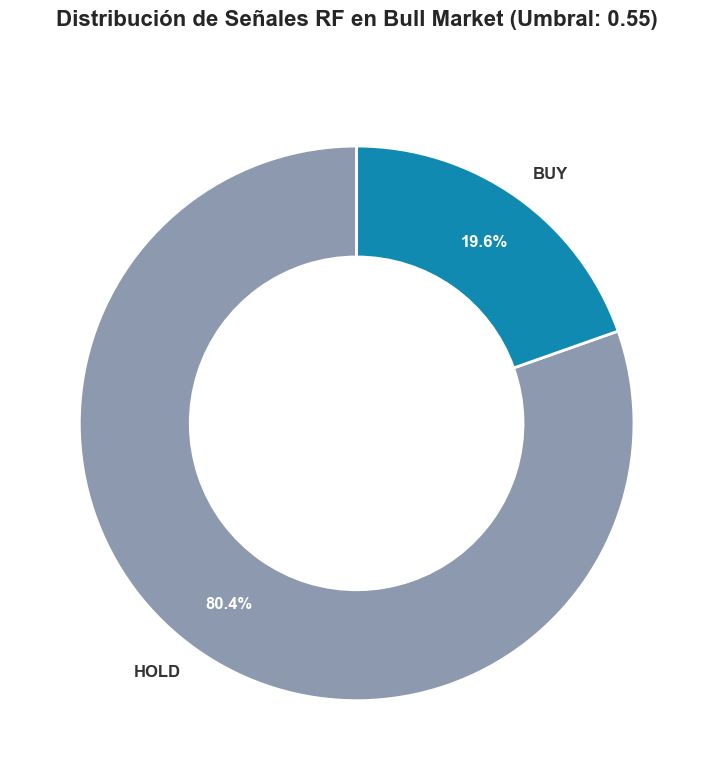

In [21]:
# --- Celda: Frecuencia de Señales Bull Market ---
signals_df_bull = generate_signals(model, test_spy_bull, buy_threshold=THRESHOLD, sell_threshold=0.45)

signal_counts_bull = signals_df_bull['signal'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))

color_map = {'BUY': '#118ab2', 'HOLD': '#8d99ae', 'SELL': '#ef233c'}
colors = [color_map.get(x, '#333333') for x in signal_counts_bull.index]

wedges, texts, autotexts = ax.pie(signal_counts_bull, labels=signal_counts_bull.index, autopct='%1.1f%%', 
                                  startangle=90, colors=colors, 
                                  wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),pctdistance=0.80,
                                  textprops=dict(fontsize=12, fontweight='bold', color='#333333'))

for autotext in autotexts:
    autotext.set_color('white')

ax.set_title(f'Distribución de Señales RF en Bull Market (Umbral: {THRESHOLD})\n', 
             fontsize=16, fontweight='bold', pad=20)



plt.tight_layout()
##plt.savefig('medium_04_bull_signal_frequency_RF.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [22]:
from sklearn.metrics import precision_score
import numpy as np
import pandas as pd

# =========================================================
# PREPARACIÓN DE DATOS (Ajusta al modelo que quieras evaluar)
# =========================================================
# Usaremos el Test Set (Bull Market) como ejemplo
df_eval = test_spy_bull.copy()
X_eval, y_eval = get_features(df_eval)
y_pred_proba = model.predict_proba(X_eval)[:, 1] # RF
THRESHOLD = 0.55


# =========================================================
# PRUEBA 1: TAMAÑO DE MUESTRA EN LA COLA
# =========================================================
n_trades_totales = np.sum(y_pred_proba >= THRESHOLD)
porcentaje_tiempo = (n_trades_totales / len(y_eval)) * 100

print(f"   PRUEBA 1: Tamaño de Muestra (> {THRESHOLD})")
print(f"   Trades identificados: {n_trades_totales} (Activo el {porcentaje_tiempo:.1f}% del tiempo)")

if n_trades_totales < 50:
    print(" VEREDICTO: Peligro (< 50). Estadísticamente no confiable.")
elif 50 <= n_trades_totales <= 200:
    print(" VEREDICTO: Dudoso (50-200). Procede con precaución.")
else:
    print(" VEREDICTO: Sólido (> 200). Empieza a ser serio.")
print("-" * 50)

# =========================================================
# PRUEBA 2: TEST CONTRA RANDOM (EL DETECTOR DE HUMO)
# =========================================================
np.random.seed(42)
# Generamos probabilidades aleatorias puras
y_pred_random = np.random.uniform(0, 1, size=len(y_eval))

# Señales de compra
signals_model = (y_pred_proba >= THRESHOLD).astype(int)
signals_random = (y_pred_random >= THRESHOLD).astype(int)

# Calculamos Precisión (Win Rate de las señales)
prec_model = precision_score(y_eval, signals_model, zero_division=0)
prec_random = precision_score(y_eval, signals_random, zero_division=0)

print(f" PRUEBA 2: Precisión vs. Ruido Aleatorio (Threshold {THRESHOLD})")
print(f"   Precisión del Modelo: {prec_model*100:.2f}%")
print(f"   Precisión del Azar:   {prec_random*100:.2f}%")

# Calculamos la "Ventaja" (Edge)
edge = prec_model - prec_random
print(f"   Edge (Ventaja real):  +{edge*100:.2f}%")

if edge < 0.05:
    print(" VEREDICTO: Es humo. El modelo no supera al azar significativamente.")
else:
    print(" VEREDICTO: Hay señal. El modelo tiene convicción real.")
print("-" * 50)

# =========================================================
# PRUEBA 3: ESTABILIDAD TEMPORAL
# =========================================================
print(f"PRUEBA 3: Estabilidad del Edge por Año")
df_eval['y_true'] = y_eval
df_eval['y_prob'] = y_pred_proba
df_eval['signal'] = signals_model
df_eval['year'] = df_eval.index.year

# Agrupamos por año para ver si el edge sobrevive al paso del tiempo
for year in df_eval['year'].unique():
    data_year = df_eval[df_eval['year'] == year]
    
    # ¿Cuántos trades hizo este año?
    trades_year = data_year['signal'].sum()
    
    # ¿Cuál fue la precisión (Win rate) de esos trades?
    # Si no hubo trades, evitamos dividir por cero
    if trades_year > 0:
        prec_year = data_year[data_year['signal'] == 1]['y_true'].mean()
    else:
        prec_year = 0.0
        
    print(f"   Año {year}: {trades_year} trades | Precisión: {prec_year*100:.1f}%")

print("\nNOTA: Busca consistencia. Si la precisión salta de 80% a 20% entre años, es sobreajuste (ruido). Si se mantiene estable (ej. >55%), tienes un sistema robusto.")
print("=" * 50)

   PRUEBA 1: Tamaño de Muestra (> 0.55)
   Trades identificados: 157 (Activo el 19.6% del tiempo)
 VEREDICTO: Dudoso (50-200). Procede con precaución.
--------------------------------------------------
 PRUEBA 2: Precisión vs. Ruido Aleatorio (Threshold 0.55)
   Precisión del Modelo: 65.61%
   Precisión del Azar:   64.44%
   Edge (Ventaja real):  +1.16%
 VEREDICTO: Es humo. El modelo no supera al azar significativamente.
--------------------------------------------------
PRUEBA 3: Estabilidad del Edge por Año
   Año 2023: 33 trades | Precisión: 69.7%
   Año 2024: 50 trades | Precisión: 70.0%
   Año 2025: 59 trades | Precisión: 67.8%
   Año 2026: 15 trades | Precisión: 33.3%

NOTA: Busca consistencia. Si la precisión salta de 80% a 20% entre años, es sobreajuste (ruido). Si se mantiene estable (ej. >55%), tienes un sistema robusto.
